# Exercise 5: Variational Auto Encoder
## Submission date: 08\06\2026, 23:59.

Submitted by:

  **Saly Jammal - 212869259**

 **Or Dinar - 207035809**

<font color='red'>Before submission, please make sure that all the plots and results are present as a colab notebook file</font>


## Configurations and initializations

This section loads libraries and configurations for various tasks for this course

In [1]:
## Standard libraries
import os
import math
import random
import numpy as np
import pandas as pd
from collections import defaultdict

## Imports for plotting
import matplotlib.pyplot as plt
plt.set_cmap('cividis')
%matplotlib inline
from matplotlib.colors import to_rgb
import seaborn as sns

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

# Torchvision
import torchvision
from torchvision.datasets import MNIST
from torchvision import transforms

# Path to the folder where the datasets are/should be downloaded (e.g. MNIST)
DATASET_PATH = "../data"

# Path to the folder where the models are saved
CHECKPOINT_PATH = "./"

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print("Using device", device)

Using device cuda:0


<Figure size 640x480 with 0 Axes>

In [2]:
# Variance of the (continuous) data noise, same value used in exercise 5
VAR = 0.091 ** 2


class ContinuousRepresentation(object):
    """Turn the discrete [0,255] pixels into a continuous representation by
    adding uniform dequantization noise, exactly as in exercise 5."""
    def __call__(self, tensor):
        tensor = tensor * 255.0
        noise = torch.rand_like(tensor)          # uniform noise in [0,1)
        tensor = (tensor + noise) / 256.0         # back to (continuous) [0,1)
        return tensor


# Transformations applied on each image: tensor + continuous representation
transform = transforms.Compose([
    transforms.ToTensor(),
    ContinuousRepresentation(),
])

# Loading the training dataset. We need to split it into a training and validation part
train_dataset = MNIST(root=DATASET_PATH, train=True, transform=transform, download=True)

train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])

# Loading the test set
test_set = MNIST(root=DATASET_PATH, train=False, transform=transform, download=True)

# We define a set of data loaders that we can use for various purposes later.
train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=0)
val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)
test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)

print('Train size:', len(train_loader.dataset))
print('Validation size:', len(val_loader.dataset))
print('Test size:', len(test_loader.dataset))

Train size: 50000
Validation size: 10000
Test size: 10000


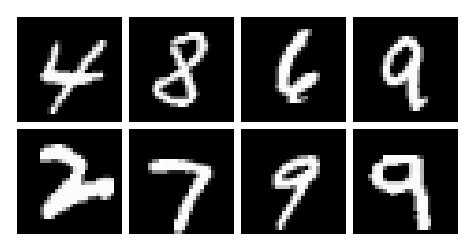

In [3]:
def show_imgs(imgs):
    num_imgs = imgs.shape[0] if isinstance(imgs, torch.Tensor) else len(imgs)
    nrow = min(num_imgs, 4)
    ncol = int(math.ceil(num_imgs/nrow))
    imgs = torchvision.utils.make_grid(imgs, nrow=nrow, pad_value=128)
    imgs = imgs.clamp(min=0, max=1)
    np_imgs = imgs.cpu().numpy()
    plt.figure(figsize=(1.5*nrow, 1.5*ncol))
    plt.imshow(np.transpose(np_imgs, (1,2,0)), interpolation='nearest')
    plt.axis('off')
    plt.show()

show_imgs([train_set[i][0] for i in range(8)])

In [4]:
class MLP(nn.Module):
    """A network with 5 linear layers and ReLU activations.
    The last layer has no ReLU so it can output negative and positive values.
    If `final_tanh` is set, a tanh squashes the output to (-1, 1) (used for the
    scale network so that exp(s) stays in a stable range)."""
    def __init__(self, dim, hidden=256, final_tanh=False):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, dim),
        )
        self.final_tanh = final_tanh

    def forward(self, x):
        out = self.net(x)
        if self.final_tanh:
            out = torch.tanh(out)
        return out


class CouplingLayer(nn.Module):
    """A single affine coupling (NF) layer.

    Given a binary mask we split the input into two halves x1 (kept) and x2
    (transformed). The transformation is:
        x1' = x1
        x2' = x2 * exp(s(x1)) + m(x1)
    where s and m are the two MLPs of the layer."""
    def __init__(self, dim, mask, hidden=256):
        super().__init__()
        self.register_buffer('mask', mask)            # 1 -> x1 (kept), 0 -> x2 (transformed)
        self.s_net = MLP(dim, hidden, final_tanh=True)   # scale network
        self.m_net = MLP(dim, hidden, final_tanh=False)  # translation network

    def forward(self, x):
        """Data -> latent direction for this layer. Returns (x', log|det J|)."""
        x1 = x * self.mask
        s = self.s_net(x1)
        m = self.m_net(x1)
        x_out = x1 + (1 - self.mask) * (x * torch.exp(s) + m)
        log_det = ((1 - self.mask) * s).sum(dim=1)
        return x_out, log_det

    def inverse(self, y):
        """Latent -> data direction for this layer (exact inverse)."""
        y1 = y * self.mask
        s = self.s_net(y1)
        m = self.m_net(y1)
        x = y1 + (1 - self.mask) * ((y - m) * torch.exp(-s))
        return x


class NormalizingFlow(nn.Module):
    def __init__(self, dim=784, n_layers=10, hidden=256):
        super().__init__()
        self.dim = dim
        self.n_layers = n_layers
        self.logs = defaultdict(list)

        # Alternating checkerboard masks: a different split for each layer.
        base = (torch.arange(dim) % 2).float()
        self.layers = nn.ModuleList([
            CouplingLayer(dim, base if i % 2 == 0 else 1.0 - base, hidden)
            for i in range(n_layers)
        ])

        # Standard Gaussian prior N(0, I) over the latent z.
        self.register_buffer('prior_mean', torch.zeros(dim))
        self.register_buffer('prior_std', torch.ones(dim))

    def log(self, key, value):
        self.logs[key].append(value)

    def prior(self):
        return torch.distributions.Normal(self.prior_mean, self.prior_std)

    def forward(self, x, return_intermediates=False):
        """Map data x to latent z. Returns z and the total log|det J|.
        If `return_intermediates` is set, also returns the list of activations
        after every layer (used for visualisations)."""
        x = x.view(x.size(0), -1)
        log_det = torch.zeros(x.size(0), device=x.device)
        inter = [x]
        for layer in self.layers:
            x, ld = layer(x)
            log_det = log_det + ld
            inter.append(x)
        if return_intermediates:
            return x, log_det, inter
        return x, log_det

    def inverse(self, z, return_intermediates=False):
        """Map latent z back to data x by inverting the layers in reverse order.
        If `return_intermediates` is set, returns the list [z, ..., x] of the
        activation after each inverse layer (11 entries for 10 layers)."""
        x = z.view(z.size(0), -1)
        inter = [x]
        for layer in reversed(self.layers):
            x = layer.inverse(x)
            inter.append(x)
        if return_intermediates:
            return x, inter
        return x

    def calc_nll(self, x):
        """Negative log-likelihood used to train the model.
        log p(x) = log p_z(f(x)) + log|det df/dx|."""
        z, log_det = self.forward(x)
        log_pz = self.prior().log_prob(z).sum(dim=1)
        log_px = log_pz + log_det
        nll = -log_px.mean()
        return nll

    @torch.no_grad()
    def sample(self, num_samples):
        z = self.prior().sample((num_samples,)).to(device)
        x = self.inverse(z)
        return x.view(num_samples, 1, 28, 28)

    def training_step(self, batch):
        nll = self.calc_nll(batch)
        self.log('train_nll', nll.item())
        self.log('train_ll', -nll.item())
        return nll

    @torch.no_grad()
    def validation_step(self, loader):
        nlls = []
        for imgs, _ in tqdm(loader, leave=False):
            imgs = imgs.to(device)
            nlls.append(self.calc_nll(imgs).item())
        nll = float(np.mean(nlls))
        self.log('val_nll', nll)
        self.log('val_ll', -nll)
        return nll

    @torch.no_grad()
    def test_step(self, loader):
        nlls = []
        for imgs, _ in tqdm(loader, leave=False):
            imgs = imgs.to(device)
            nlls.append(self.calc_nll(imgs).item())
        nll = float(np.mean(nlls))
        self.log('test_nll', nll)
        self.log('test_ll', -nll)
        return nll

## Model Training


## Assignment 1

We instantiate the flow (10 coupling layers, each with two 5-layer MLPs of hidden size 256) and train it for 30 epochs with Adam, minimizing the negative log-likelihood. We use the same training process as in exercise 5 (`Adam` + `StepLR` scheduler + `torch.compile`).

In [5]:
model = NormalizingFlow(dim=28 * 28, n_layers=10, hidden=256).to(device)
print("Num params: {:,}".format(sum(p.numel() for p in model.parameters())))

model = torch.compile(model.to(device))

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, 1, gamma=0.99)
epochs = 30

Num params: 11,996,480


In [6]:
# Training loop
for epoch in range(epochs):
    model.train()
    print(f"Epoch {epoch + 1}/{epochs}")

    for imgs, _ in tqdm(train_loader, leave=False):
        imgs = imgs.to(device)
        optimizer.zero_grad()
        loss = model.training_step(imgs)
        loss.backward()
        optimizer.step()

    scheduler.step()
    val_nll = model.validation_step(val_loader)
    print(f"  val NLL: {val_nll:.2f}  (log-likelihood: {-val_nll:.2f})")

# Test loop
model.eval()
final_nll = model.test_step(test_loader)
print(f"Final test NLL: {final_nll:.2f}  |  test log-likelihood: {-final_nll:.2f} nats")

# Save the model
torch.save(model.state_dict(), 'nf_model.pth')

Epoch 1/30


  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

  val NLL: -1831.97  (log-likelihood: 1831.97)
Epoch 2/30


  0%|          | 0/390 [00:00<?, ?it/s]

...

  0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

  val NLL: -2302.66  (log-likelihood: 2302.66)


  0%|          | 0/79 [00:00<?, ?it/s]

Final test NLL: -2290.19  |  test log-likelihood: 2290.19 nats


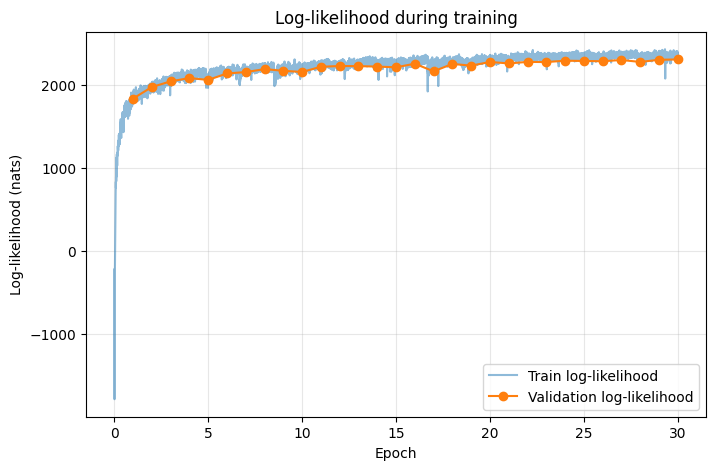

Test set log-likelihood: 2290.19 nats (NLL = -2290.19)


In [7]:
# Log-likelihood curves for training and validation data
steps_per_epoch = max(1, len(model.logs['train_ll']) // len(model.logs['val_ll']))
train_x = [i / steps_per_epoch for i in range(len(model.logs['train_ll']))]
val_x = list(range(1, len(model.logs['val_ll']) + 1))

plt.figure(figsize=(8, 5))
plt.plot(train_x, model.logs['train_ll'], label='Train log-likelihood', alpha=0.5)
plt.plot(val_x, model.logs['val_ll'], label='Validation log-likelihood', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Log-likelihood (nats)')
plt.title('Log-likelihood during training')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Test set log-likelihood: {model.logs['test_ll'][-1]:.2f} nats "
      f"(NLL = {model.logs['test_nll'][-1]:.2f})")

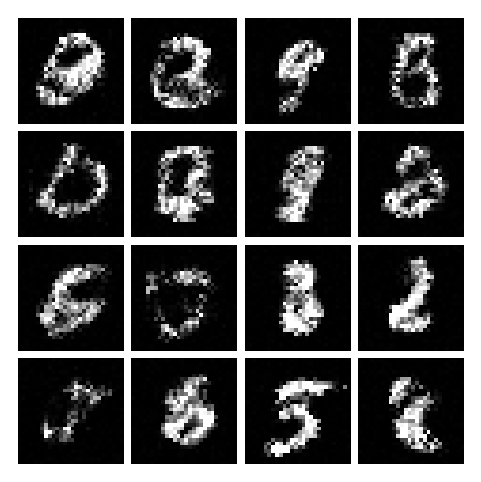

In [8]:
# Generate a few samples from the trained model
model.eval()
sampled_images = model.sample(num_samples=16)
show_imgs(sampled_images)

## Assignment 2 - From latent z to data x

We draw 7 samples from the latent prior $z \sim N(0, I)$ and pass each through the inverse flow, showing the intermediate result after every NF layer. Each row shows 11 images: the leftmost is the latent sample $z$ and the rightmost is the final data sample $x$, with the 10 intermediate outputs in between.

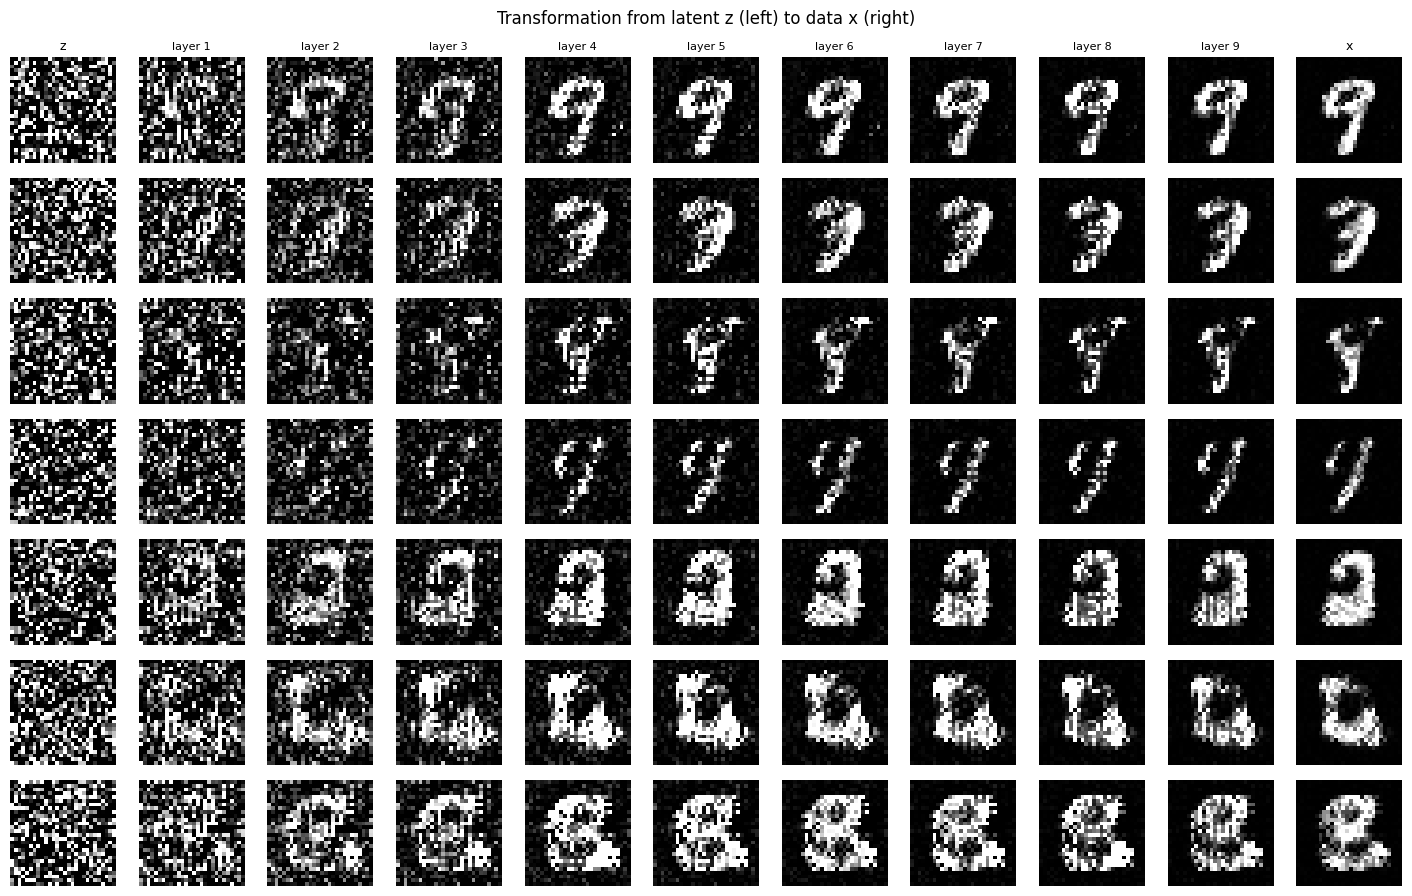

In [9]:
model.eval()
n_rows = 7

with torch.no_grad():
    z = torch.randn(n_rows, model.dim, device=device)
    # inter is a list of 11 tensors: [z, after inv-layer 10, ..., x]
    x_final, inter = model.inverse(z, return_intermediates=True)

n_cols = len(inter)  # = 11 (latent + one per NF layer)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.3 * n_cols, 1.3 * n_rows))
for r in range(n_rows):
    for c in range(n_cols):
        img = inter[c][r].view(28, 28).clamp(0, 1).cpu().numpy()
        ax = axes[r, c]
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if r == 0:
            if c == 0:
                ax.set_title('z', fontsize=9)
            elif c == n_cols - 1:
                ax.set_title('x', fontsize=9)
            else:
                ax.set_title(f'layer {c}', fontsize=8)

plt.suptitle('Transformation from latent z (left) to data x (right)', fontsize=12)
plt.tight_layout()
plt.show()

## Assignment 3 - Latent traversals

For each of 3 pairs of different digits we encode both images to their latent representation $z_1, z_2$ (using the forward flow), take 10 equally-spaced points along the straight line between them, and decode each point back to image space with the inverse flow. We can see the first digit smoothly transform into the second.

/home/ordinary/ordinaryLib/myenv/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:194: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


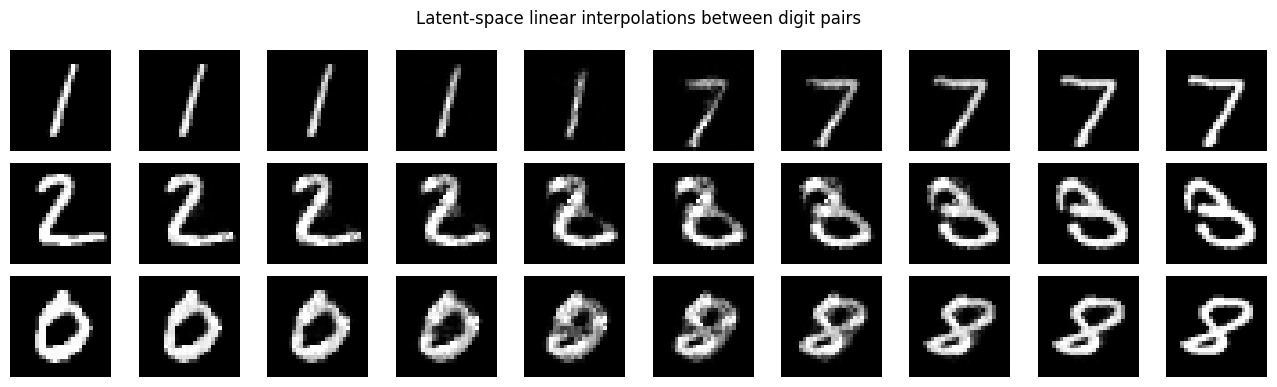

In [10]:
model.eval()

# Collect one image per digit from the test set
images_by_label = defaultdict(list)
for imgs, labels in test_loader:
    for img, lbl in zip(imgs, labels):
        images_by_label[lbl.item()].append(img)
    if all(len(images_by_label[k]) >= 1 for k in range(10)):
        break

# 3 pairs of different digits
pairs = [
    (images_by_label[1][0], images_by_label[7][0]),  # 1 -> 7
    (images_by_label[2][0], images_by_label[3][0]),  # 2 -> 3
    (images_by_label[0][0], images_by_label[8][0]),  # 0 -> 8
]

n_steps = 10
alphas = torch.linspace(0, 1, n_steps).to(device)

fig, axes = plt.subplots(len(pairs), n_steps, figsize=(1.3 * n_steps, 1.3 * len(pairs)))
for idx, (img1, img2) in enumerate(pairs):
    x1 = img1.unsqueeze(0).to(device)
    x2 = img2.unsqueeze(0).to(device)
    with torch.no_grad():
        z1, _ = model(x1)
        z2, _ = model(x2)
        for j, a in enumerate(alphas):
            z_interp = (1 - a) * z1 + a * z2
            x_rec = model.inverse(z_interp).view(28, 28).clamp(0, 1).cpu().numpy()
            ax = axes[idx, j]
            ax.imshow(x_rec, cmap='gray')
            ax.axis('off')

plt.suptitle('Latent-space linear interpolations between digit pairs', fontsize=12)
plt.tight_layout()
plt.show()

## Summary

We implemented a RealNVP-style normalizing flow on MNIST. Each image is dequantized into a continuous representation (as in exercise 5) and flattened into a 784-dimensional vector. The model stacks **10 affine coupling layers**; each layer keeps one half of the vector fixed and applies an affine transform $x_2' = x_2 \exp(s_\theta(x_1)) + m_\theta(x_1)$ to the other half. The scale $s_\theta$ and shift $m_\theta$ are produced by two MLPs, each with 5 linear layers and ReLU activations (no ReLU on the last layer; the scale network uses a `tanh` to keep $\exp(s)$ in a stable range). Consecutive layers use **alternating checkerboard masks** so that every coordinate gets transformed.

Because every coupling layer is invertible with an easy-to-compute triangular Jacobian (log-determinant equal to the sum of the scales), we can train the model by directly maximizing the exact log-likelihood $\log p(x) = \log p_z(f(x)) + \log\lvert\det \partial f/\partial x\rvert$ under a standard Gaussian prior $N(0, I)$.

**Results.**
- *Assignment 1:* The training/validation log-likelihood curves increase steadily over the 30 epochs and the reported test log-likelihood confirms the model fits the data well. The samples drawn from the prior and pushed through the inverse flow mostly look like valid digits.
- *Assignment 2:* Visualising the inverse pass layer-by-layer shows the unstructured Gaussian noise $z$ gradually being shaped into a recognizable digit as it passes through the NF layers.
- *Assignment 3:* Linearly interpolating in latent space between two digits produces a smooth morph from one digit to the other, showing the flow has learned a meaningful, continuous latent representation.